[2026-08-04 22:28:42] [info     ] 计算分数(仅加载权重推理, 不重训)             end='2024-12-31 23:59:59' start='2024-01-01 00:00:00'
[2026-08-04 22:28:43] [info     ] 已加载模型                          device=cuda path=/home/aiuser/work/transformer_multifreq_model.json
[2026-08-04 22:28:43] [info     ] 构建测试集并预测(chunk)                end='2024-01-31 23:59:59' start='2024-01-01 00:00:00'
[2026-08-04 22:28:55] [info     ] infer 集构建完成                    days=22 elapsed=11.53 samples=21976
[2026-08-04 22:28:56] [info     ] 构建测试集并预测(chunk)                end='2024-02-29 23:59:59' start='2024-02-01 00:00:00'
[2026-08-04 22:29:05] [info     ] infer 集构建完成                    days=15 elapsed=9.47 samples=14998
[2026-08-04 22:29:05] [info     ] 构建测试集并预测(chunk)                end='2024-03-31 23:59:59' start='2024-03-01 00:00:00'
[2026-08-04 22:29:17] [info     ] infer 集构建完成                    days=21 elapsed=11.71 samples=20986
[2026-08-04 22:29:18] [info     ] 构建测试集并预测(chunk)                end='2024-04-30 23:59:59

时段,IC
2024-01-15~2024-02-08,-0.0208
2024-09-24~2024-10-08,-0.0038

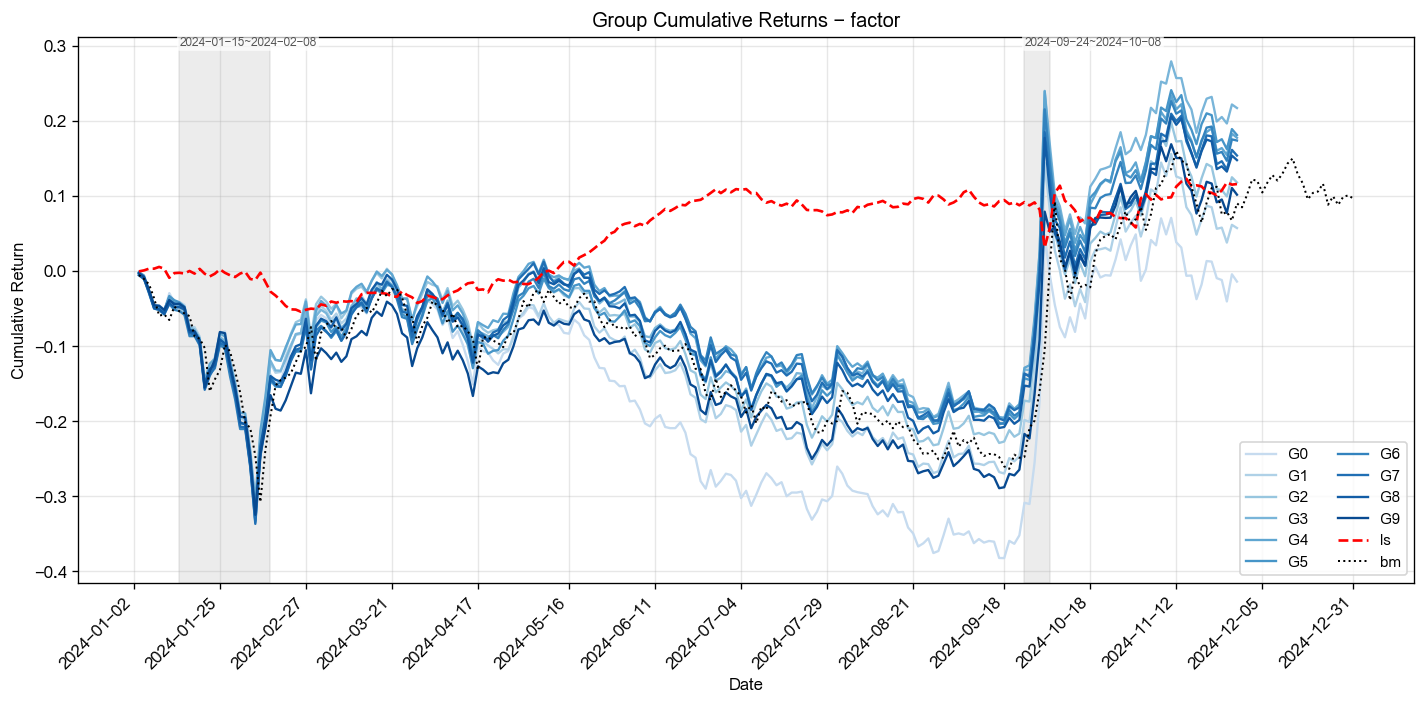
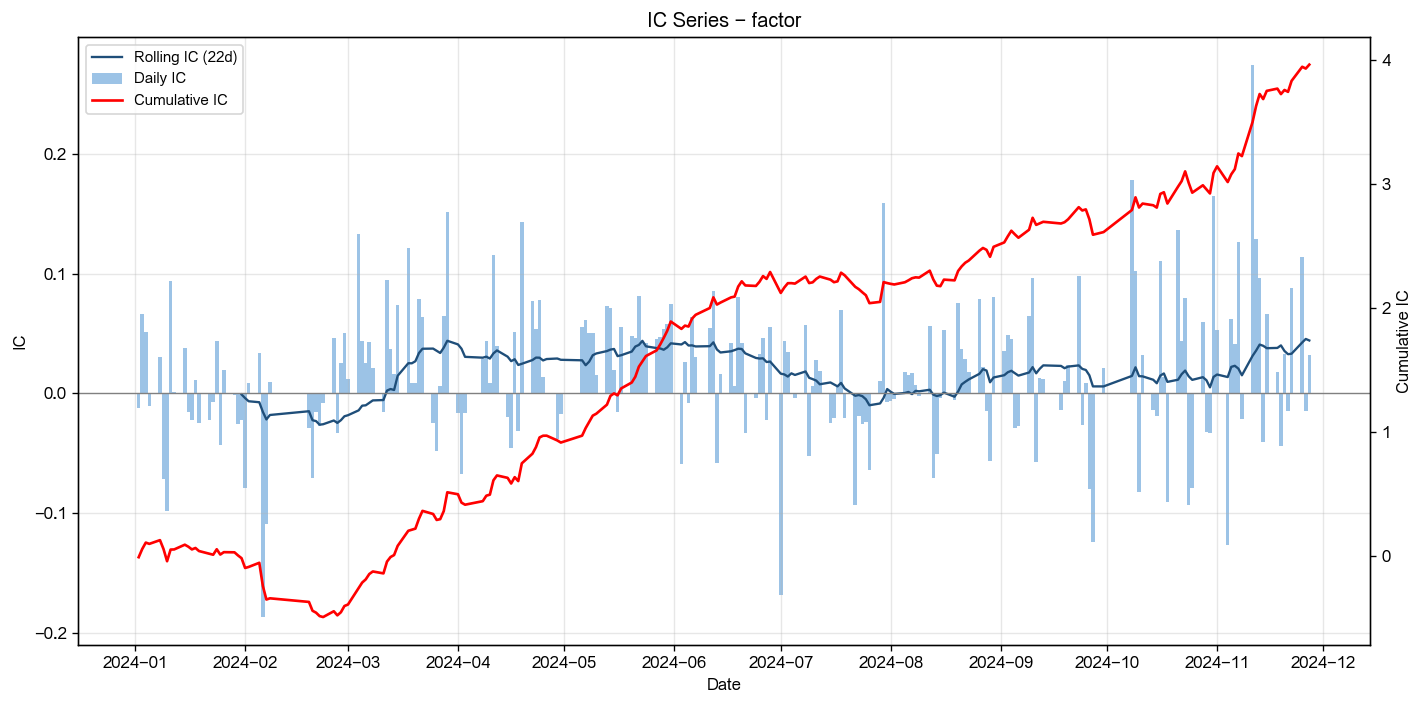
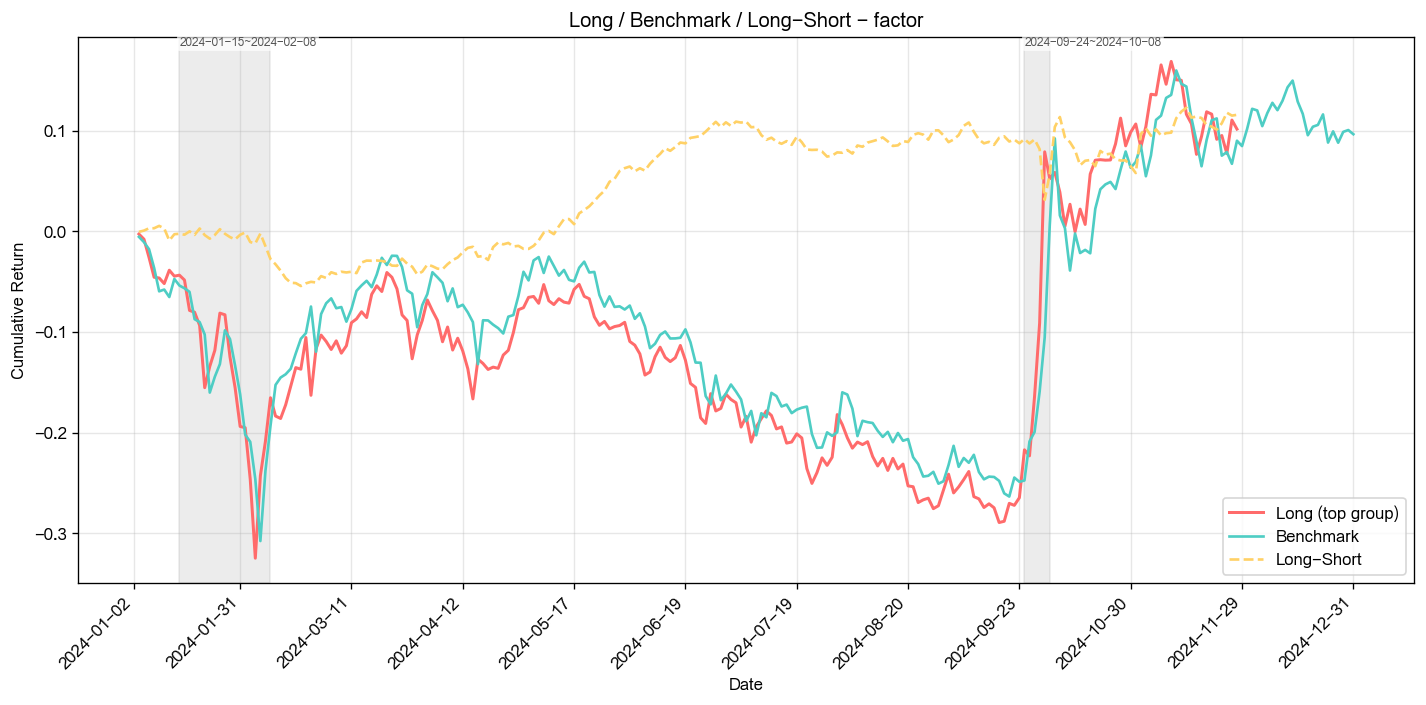
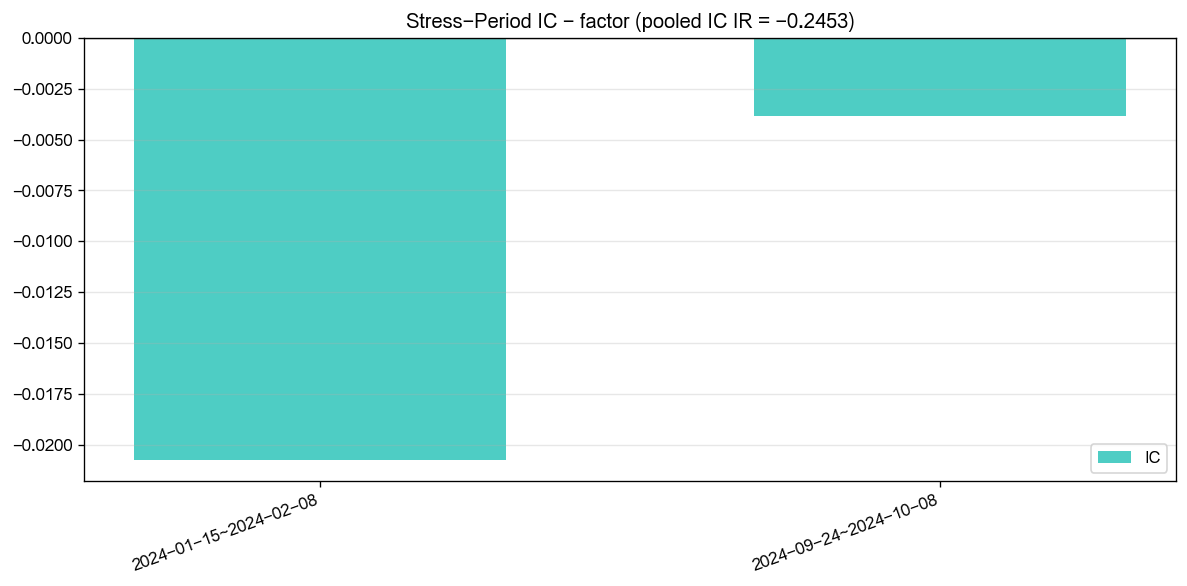
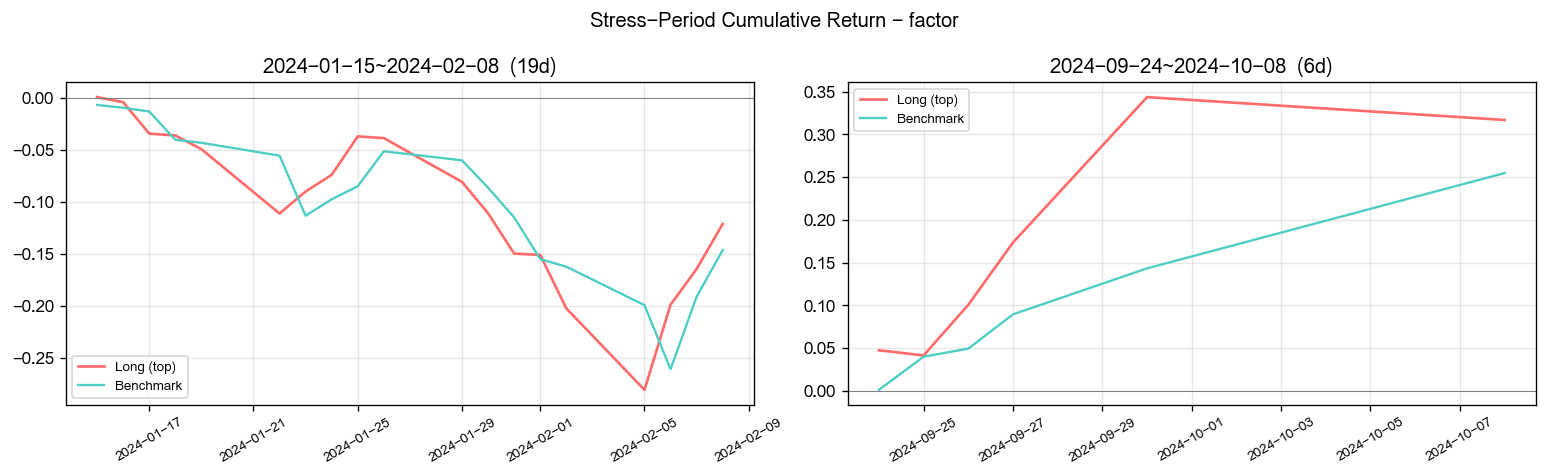

[2026-08-04 22:31:27] [warning  ] 未传入因子池，跳过因子池回归检验
[2026-08-04 22:31:28] [warning  ] 返回的Outputs实例(size=35434067) 大于 64K, 将不会被缓存
[2026-08-04 22:31:28] [info     ] bigalpha_eval.v4 运行完成 [13.650s].


In [1]:
# -*- coding: utf-8 -*-
"""
多频率端到端 Transformer —— 推理侧脚本(predict-only)

只负责推理: 加载 transformer_train.py 训练产出的
transformer_multifreq_model.json, 在平台注入的测试区间上打分, 不训练。

>>> 提交时注意 <<<
赛制只允许提交一个 notebook, 其余可以是普通文件, 但"调用评估模块的代码
必须放在 notebook 里"。所以实际提交时, 把本文件里 main() 及 if __name__
部分的逻辑粘贴进你的 notebook, 同时把 transformer_train.py 和训练好的
transformer_multifreq_model.json 作为附带文件一起上传(与官方 demo 的
三文件约定完全一致, 只是内容换成了多频率版本)。

标准化说明: 新版 transformer_train.py 里标准化已经改为按天做横截面
z-score(daily_cross_section_standardize), train/infer 都是各自用当天
横截面自己算 mean/std, 不再依赖训练阶段存下的全局 stats。因此这里不再
从 ckpt 里读取/使用 stats 字段(旧版接口已废弃)。
"""
import os
import numpy as np
import pandas as pd
import dai
import torch
import structlog

from transformer_train import (
    MODEL_PATH, BATCH, FREQ_NAMES, DEV_TABLES,
    MultiFreqStockModel, build_dataset, pool, train_and_save, load_model,
)

logger = structlog.get_logger()


def _month_chunks(start_date, end_date):
    """把 [start_date, end_date] 按自然月切成若干左闭右闭子区间，
    首尾月做裁剪，避免越界到 start_date/end_date 之外。"""
    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)
    periods = pd.period_range(start_ts, end_ts, freq="M")
    chunks = []
    for p in periods:
        c_start = max(p.start_time, start_ts)
        c_end = min(p.end_time, end_ts)
        chunks.append((c_start, c_end))
    return chunks


def main(datasources, start_date, end_date, chunk_freq="M"):
    """分 chunk 推理: 按月(或更细粒度)切分测试区间, 逐 chunk 调用
    build_dataset 打分, 及时释放显存/内存, 最后拼成一个大 DataFrame
    再做统一的中证1000对齐。chunk_freq 目前仅实现按月, 若平台内存
    仍不够, 可把 _month_chunks 换成按周(freq="W")的版本。"""
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if not os.path.exists(MODEL_PATH):
        raise FileNotFoundError(
            f"未找到模型文件 {MODEL_PATH}; 请先运行 train_and_save(...) 训练并保存, 再随 notebook 一起上传")

    ckpt = load_model(MODEL_PATH, map_location=device)
    model = MultiFreqStockModel(**ckpt["model_cfg"]).to(device)
    model.load_state_dict(ckpt["state_dict"])
    model.eval()
    logger.info("已加载模型", path=MODEL_PATH, device=str(device))

    score_chunks = []
    for c_start, c_end in _month_chunks(start_date, end_date):
        c_start_s = c_start.strftime("%Y-%m-%d %H:%M:%S")
        c_end_s = c_end.strftime("%Y-%m-%d %H:%M:%S")
        logger.info("构建测试集并预测(chunk)", start=c_start_s, end=c_end_s)

        Xte, _, idx_df = build_dataset(
            datasources, c_start_s, c_end_s, "infer",
            pool(c_start_s, c_end_s))

        n = len(idx_df)
        if n == 0:
            logger.info("该 chunk 无样本, 跳过", start=c_start_s, end=c_end_s)
            continue

        tensors = {name: torch.from_numpy(Xte[name]) for name in FREQ_NAMES}
        preds = []
        with torch.no_grad():
            for j in range(0, n, BATCH):
                xb_dict = {name: tensors[name][j:j + BATCH].to(device) for name in FREQ_NAMES}
                preds.append(model(xb_dict).cpu().numpy())

        idx_df = idx_df.copy()
        idx_df["score"] = np.concatenate(preds).astype(np.float64)
        score_chunks.append(idx_df[["date", "instrument", "score"]])

        # 这几行是分 chunk 的核心目的: 及时释放上一个 chunk 占用的内存/显存
        del Xte, tensors, preds, idx_df
        if device.type == "cuda":
            torch.cuda.empty_cache()
        import gc
        gc.collect()

    if not score_chunks:
        raise RuntimeError("所有 chunk 均无有效样本, 请检查 start_date/end_date 或 pool()")

    idx_df = pd.concat(score_chunks, ignore_index=True)

    # ---------- 对齐中证 1000 + 规范输出 (整体做一次, 数据量已经很小了) ----------
    stk = dai.query("SELECT date, instrument FROM bigalpha_2026_instruments",
                     filters={"date": [start_date, end_date]}).df()
    result = (pd.merge(idx_df, stk, on=["date", "instrument"], how="inner")
                .replace([np.inf, -np.inf], np.nan).dropna(subset=["score"])
                .drop_duplicates(["date", "instrument"])[["date", "instrument", "score"]]
                .reset_index(drop=True))
    logger.info("分数构建完成", rows=len(result), days=result["date"].nunique(),
                instruments=result["instrument"].nunique())
    return result


if __name__ == "__main__":
    from bigmodule import M

    datasources = {name: DEV_TABLES[name] for name in FREQ_NAMES}

    # 本地首次运行: 若权重文件不存在, 先训练并保存(正式做法是单独执行一次
    # `python transformer_train.py` 训练, 这里仅为本地便捷兜底)
    if not os.path.exists(MODEL_PATH):
        logger.info("未发现已保存模型, 开始训练", path=MODEL_PATH)
        train_and_save(datasources)

    # 本地用一小段区间模拟「平台注入的测试集区间」(训练区间已在 transformer_train.py 内写死)
    start_date, end_date = "2024-01-01 00:00:00", "2024-12-31 23:59:59"
    logger.info("计算分数(仅加载权重推理, 不重训)", start=start_date, end=end_date)
    score_data = main(datasources, start_date, end_date)
    print(score_data.head())

    # 评估系统: 分数经风格剔除后等价于每日单因子, show=True 画绩效图 (IC / 分组 / 压力期)
    logger.info("开始评估分数")
    result = M.bigalpha_eval._latest(factor_data=score_data, show=True)
